# Challenger 3/5: LightGBM — Dementia Screening Challenger

**Benchmark protocol — identical to `modelx.ipynb` (logistic regression incumbent).**

| Element | Locked value |
|---|---|
| Data | `outputs/clean_data.csv` (11,924 rows, modelx §4 cleaning) |
| Split | 80/20 stratified, `random_state=42` — asserted to reproduce modelx exactly |
| Features | 28 (8 numeric + 10 categorical + 9 binary + income-missing flag); `cognitive_screen_score` quarantined (plan §4.2H) |
| CV | 5-fold stratified on train (default AND tuned hyperparameters) |
| Tuning | Randomised search, 3-fold inner CV, ROC-AUC objective, train partition only |
| Operating points | Youden's J; screening = max specificity at sensitivity >= 0.80 |
| Calibration | slope/intercept (modelx §6.4 method) + OOF-fitted isotonic variant |
| Importances | permutation (ROC-AUC drop, 10 repeats, hold-out) — comparable across all models |

**Incumbent to beat (modelx hold-out): ROC-AUC 0.771 | PR-AUC 0.337 | Brier 0.063 | CV AUC 0.785 +/- 0.011.**

User ranking context: **Challenger 3/5 of 5** — accuracy potential *High*, interpretability *Medium*.


In [1]:
# --- Challenger benchmark: protocol identical to modelx.ipynb (LR incumbent) ------------
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.inspection import permutation_importance
from sklearn.metrics import (average_precision_score, brier_score_loss,
                             classification_report, confusion_matrix,
                             precision_recall_curve, roc_auc_score, roc_curve)
from sklearn.model_selection import ParameterSampler, StratifiedKFold, train_test_split

try:
    from sklearn.metrics import calibration_curve
except ImportError:
    from sklearn.calibration import calibration_curve

RANDOM_STATE = 42          # single seed for split, folds and estimators (plan §6.1.3)
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

OUT_DIR = Path("outputs")
BENCH = OUT_DIR / "benchmark"
BENCH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "LightGBM"
SLUG = "lightgbm"

# Incumbent to beat — modelx.ipynb §6.1 (CV) and §6.3 (hold-out) results.
LR_BASELINE = {"cv_auc": 0.785, "cv_sd": 0.011,
               "holdout_auc": 0.771, "holdout_pr": 0.337, "holdout_brier": 0.063}
print("Environment ready — challenger:", MODEL_NAME)


Environment ready — challenger: LightGBM


In [2]:
# --- Data + split: byte-for-byte the modelx.ipynb §5 recipe ----------------------------
TARGET = "dementia_status"
NUMERIC_FEATURES = ["age_years", "education_years", "monthly_household_income_usd",
                    "systolic_bp_mmhg", "diastolic_bp_mmhg", "bmi_kg_m2", "gds15_score",
                    "fruit_veg_servings_per_day"]
CATEGORICAL_FEATURES = ["province", "residence", "sex", "marital_status",
                        "employment_status", "hiv_status", "smoking_status", "alcohol_use",
                        "physical_activity_level", "social_engagement"]
BINARY_FEATURES = ["lives_alone", "hypertension_dx", "takes_bp_medication", "diabetes_dx",
                   "prior_stroke", "head_injury_history", "family_history_dementia",
                   "hearing_difficulty", "vision_difficulty"]

clean = pd.read_csv(OUT_DIR / "clean_data.csv", keep_default_na=False, na_values=[""])
clean["income_missing"] = clean["monthly_household_income_usd"].isna().astype(int)

X = clean[NUMERIC_FEATURES + CATEGORICAL_FEATURES + BINARY_FEATURES].copy()
X[BINARY_FEATURES] = X[BINARY_FEATURES].apply(lambda s: pd.to_numeric(s, errors="coerce").astype(float))
X["income_missing"] = clean.loc[X.index, "income_missing"]
y = clean[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

# Sanity anchors: these MUST match modelx or every comparison below is void.
expected = (9539, 2385, 767, 192)
actual = (len(X_train), len(X_test), int(y_train.sum()), int(y_test.sum()))
assert actual == expected, f"Split mismatch vs modelx: {actual} != {expected}"
print(f"Train {actual[0]:,} ({y_train.mean():.1%} events) | "
      f"Hold-out {actual[1]:,} ({y_test.mean():.1%} events) — reproduces modelx")


Train 9,539 (8.0% events) | Hold-out 2,385 (8.1% events) — reproduces modelx


## 1 · Model & representation

LightGBM — leaf-wise growth with native categorical support via the fit kwarg; -1 codes land in LightGBM's own missing-category path.

In [3]:
# --- Model + representation ------------------------------------------------------------
# Tree-native representation: numerics keep NaN (all three boosting backends split on
# missingness natively); categoricals become FIXED ordinal codes from a train-fit
# encoder (NaN -> own level "Missing"; unseen hold-out levels -> -1), so every fold
# and the hold-out share one deterministic encoding.
from sklearn.preprocessing import OrdinalEncoder

def make_representation(X_tr, X_te):
    Xtr, Xte = X_tr.copy(), X_te.copy()
    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    enc.fit(Xtr[CATEGORICAL_FEATURES].fillna("Missing"))
    Xtr[CATEGORICAL_FEATURES] = enc.transform(
        Xtr[CATEGORICAL_FEATURES].fillna("Missing")).astype(np.int64)
    Xte[CATEGORICAL_FEATURES] = enc.transform(
        Xte[CATEGORICAL_FEATURES].fillna("Missing")).astype(np.int64)
    return Xtr, Xte

X_train_m, X_test_m = make_representation(X_train, X_test)
print(f"Design matrix: {X_train_m.shape[0]:,} x {X_train_m.shape[1]} "
      f"({len(CATEGORICAL_FEATURES)} categoricals as fixed ordinal codes)")

from lightgbm import LGBMClassifier

# LightGBM takes the ordinal codes as categoricals via the fit kwarg (FIT_KWARGS
# below); -1 is LightGBM's own "missing" category code, which is what we want for
# unseen levels.
def make_model(**over):
    params = dict(n_estimators=400, num_leaves=31, learning_rate=0.1,
                  min_child_samples=20, subsample=0.9, subsample_freq=1,
                  colsample_bytree=0.9)
    base = dict(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
                importance_type="gain")
    return LGBMClassifier(**{**base, **params})

PARAM_GRID = {"n_estimators": [200, 500, 800], "num_leaves": [15, 31, 63],
              "learning_rate": [0.03, 0.1], "min_child_samples": [20, 60],
              "subsample": [0.8, 1.0], "colsample_bytree": [0.7, 1.0]}


Design matrix: 9,539 x 28 (10 categoricals as fixed ordinal codes)


## 2 · Cross-validated performance (default vs tuned)

In [4]:
# --- Shared evaluation machinery (identical text in every challenger notebook) ---------
CV5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
CV3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
FIT_KWARGS = {"categorical_feature": CATEGORICAL_FEATURES}

def cv_evaluate(make_model, Xdf, yser, cv=CV5):
    """Stratified CV: fresh model per fold, fitted on the fold-train only."""
    rows = []
    for fold, (tr, va) in enumerate(cv.split(Xdf, yser), 1):
        model = make_model()
        model.fit(Xdf.iloc[tr], yser.iloc[tr], **FIT_KWARGS)
        p = model.predict_proba(Xdf.iloc[va])[:, 1]
        rows.append({"fold": fold,
                     "roc_auc": roc_auc_score(yser.iloc[va], p),
                     "pr_auc": average_precision_score(yser.iloc[va], p),
                     "brier": brier_score_loss(yser.iloc[va], p)})
    tab = pd.DataFrame(rows)
    summary = {c: (float(tab[c].mean()), float(tab[c].std()))
               for c in ["roc_auc", "pr_auc", "brier"]}
    return tab, summary

def random_search(make_model, grid, Xdf, yser, n_iter=12, cv=CV3):
    """Manual randomised search (3-fold, ROC-AUC). Works for every backend, including
    those whose fit() needs extra kwargs (e.g. LightGBM categorical features)."""
    sampler = list(ParameterSampler(grid, n_iter=n_iter, random_state=RANDOM_STATE))
    records = []
    for i, params in enumerate(sampler, 1):
        aucs = []
        for tr, va in cv.split(Xdf, yser):
            model = make_model(**params)
            model.fit(Xdf.iloc[tr], yser.iloc[tr], **FIT_KWARGS)
            aucs.append(roc_auc_score(yser.iloc[va],
                                      model.predict_proba(Xdf.iloc[va])[:, 1]))
        records.append({"config": i, **params,
                        "cv_auc": float(np.mean(aucs)), "cv_sd": float(np.std(aucs))})
    tab = pd.DataFrame(records).sort_values("cv_auc", ascending=False).reset_index(drop=True)
    row = tab.iloc[0]
    best = {k: (row[k].item() if hasattr(row[k], "item") else row[k]) for k in grid}
    return tab, best

def operating_points(y_true, p):
    """Youden J + mandated screening point (max specificity at sensitivity >= 0.80)."""
    fpr, tpr, thr = roc_curve(y_true, p)
    thr_youden = float(thr[np.argmax(tpr - fpr)])
    valid = np.where(tpr >= 0.80)[0]
    thr_screen = float(thr[valid[0]] if len(valid) else thr[-1])
    def ss(t):
        yhat = (p >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, yhat).ravel()
        return {"sensitivity": tp / (tp + fn), "specificity": tn / (tn + fp),
                "PPV": tp / (tp + fp), "NPV": tn / (tn + fn)}
    return thr_youden, thr_screen, {"Youden J": ss(thr_youden),
                                    "Screening (sens>=0.80)": ss(thr_screen)}

def calib_slope_intercept(y_true, p):
    """Logistic recalibration fit on the logits (modelx §6.4 method)."""
    from sklearn.linear_model import LogisticRegression
    eps = 1e-6
    fit = LogisticRegression(C=1e6).fit(
        np.log((p + eps) / (1 - p + eps)).reshape(-1, 1), y_true)
    return float(fit.coef_[0][0]), float(fit.intercept_[0])


In [5]:
# --- Step 1: default hyperparameters, 5-fold CV (the honest starting point) ------------
default_tab, default_sum = cv_evaluate(make_model, X_train_m, y_train)
display(default_tab.round(4))
print(f"Default CV ROC-AUC {default_sum['roc_auc'][0]:.3f} +/- {default_sum['roc_auc'][1]:.3f} "
      f"| PR-AUC {default_sum['pr_auc'][0]:.3f} | Brier {default_sum['brier'][0]:.4f}   "
      f"(LR incumbent: {LR_BASELINE['cv_auc']:.3f} +/- {LR_BASELINE['cv_sd']:.3f})")


,fold,roc_auc,pr_auc,brier
0,1,0.7443,0.2697,0.0701
1,2,0.7337,0.2958,0.0691
2,3,0.7641,0.3117,0.0692
3,4,0.7413,0.2939,0.0700
4,5,0.7251,0.2559,0.0726


Default CV ROC-AUC 0.742 +/- 0.015 | PR-AUC 0.285 | Brier 0.0702   (LR incumbent: 0.785 +/- 0.011)


In [6]:
# --- Step 2: randomised search (3-fold, ROC-AUC) + tuned 5-fold CV ---------------------
search_tab, best_params = random_search(make_model, PARAM_GRID, X_train_m, y_train,
                                        n_iter=12)
print("Top configurations (3-fold CV):")
display(search_tab.round(4))
print("Best params:", best_params)

tuned_tab, tuned_sum = cv_evaluate(lambda: make_model(**best_params), X_train_m, y_train)

comparison = pd.DataFrame({
    "CV ROC-AUC": [LR_BASELINE["cv_auc"], default_sum["roc_auc"][0], tuned_sum["roc_auc"][0]],
    "CV PR-AUC":  [0.342, default_sum["pr_auc"][0], tuned_sum["pr_auc"][0]],
    "CV Brier":   [0.063, default_sum["brier"][0], tuned_sum["brier"][0]],
}, index=["LR (modelx)", MODEL_NAME + " default", MODEL_NAME + " tuned"])
display(comparison.round(4))


Top configurations (3-fold CV):


,config,subsample,num_leaves,n_estimators,min_child_samples,learning_rate,colsample_bytree,cv_auc,cv_sd
0,1,1.0,31,500,20,0.10,1.0,0.7387,0.0068
1,2,1.0,15,200,60,0.03,0.7,0.7387,0.0068
2,3,0.8,63,500,20,0.03,1.0,0.7387,0.0068
3,4,1.0,15,500,60,0.03,1.0,0.7387,0.0068
4,5,0.8,31,200,60,0.10,0.7,0.7387,0.0068
5,6,0.8,15,800,20,0.03,0.7,0.7387,0.0068
6,7,0.8,15,500,60,0.10,1.0,0.7387,0.0068
7,8,1.0,63,500,60,0.10,0.7,0.7387,0.0068
8,9,0.8,15,800,60,0.10,0.7,0.7387,0.0068
9,10,0.8,15,200,60,0.03,0.7,0.7387,0.0068


Best params: {'n_estimators': 500.0, 'num_leaves': 31.0, 'learning_rate': 0.1, 'min_child_samples': 20.0, 'subsample': 1.0, 'colsample_bytree': 1.0}


,CV ROC-AUC,CV PR-AUC,CV Brier
LR (modelx),0.7850,0.3420,0.0630
LightGBM default,0.7417,0.2854,0.0702
LightGBM tuned,0.7417,0.2854,0.0702


## 3 · Hold-out evaluation (single final fit)

,sensitivity,specificity,PPV,NPV,threshold
Youden J,0.688,0.652,0.147,0.960,0.010022
Screening (sens>=0.80),0.802,0.456,0.114,0.963,0.003723


Hold-out ROC-AUC = 0.725 (LR 0.771, delta -0.046) | PR-AUC = 0.260 (LR 0.337) | Brier = 0.071 (LR 0.063)


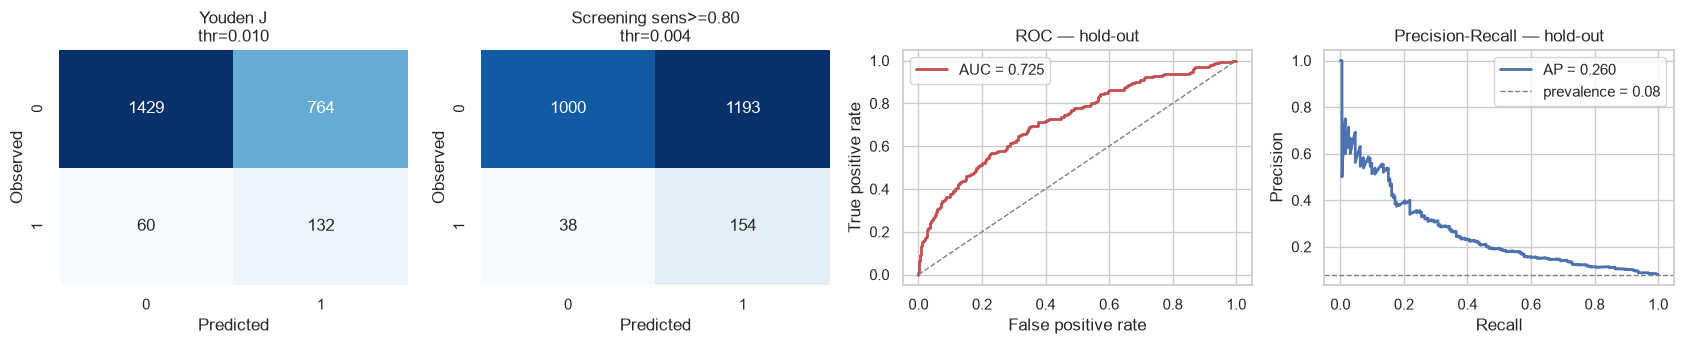

              precision    recall  f1-score   support

 No dementia       0.96      0.65      0.78      2193
    Dementia       0.15      0.69      0.24       192

    accuracy                           0.65      2385
   macro avg       0.55      0.67      0.51      2385
weighted avg       0.89      0.65      0.73      2385



In [7]:
# --- Step 3: single final fit on the full training partition, one pass at hold-out -----
final_model = make_model(**best_params)
final_model.fit(X_train_m, y_train, **FIT_KWARGS)
proba_raw = final_model.predict_proba(X_test_m)[:, 1]

auc = roc_auc_score(y_test, proba_raw)
pr_auc = average_precision_score(y_test, proba_raw)
brier_raw = brier_score_loss(y_test, proba_raw)
thr_youden, thr_screen, points = operating_points(y_test, proba_raw)

pts = pd.DataFrame(points).T.round(3)
pts["threshold"] = [thr_youden, thr_screen]
display(pts)
print(f"Hold-out ROC-AUC = {auc:.3f} (LR 0.771, delta {auc - LR_BASELINE['holdout_auc']:+.3f}) | "
      f"PR-AUC = {pr_auc:.3f} (LR 0.337) | Brier = {brier_raw:.3f} (LR 0.063)")

fig, axes = plt.subplots(1, 4, figsize=(17, 3.6))
for ax, (name, thr) in zip(axes[:2], [("Youden J", thr_youden),
                                      ("Screening sens>=0.80", thr_screen)]):
    cm = confusion_matrix(y_test, (proba_raw >= thr).astype(int))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Observed")
    ax.set_title(f"{name}\nthr={thr:.3f}")
fpr, tpr, _ = roc_curve(y_test, proba_raw)
axes[2].plot(fpr, tpr, color="#c44e52", lw=2, label=f"AUC = {auc:.3f}")
axes[2].plot([0, 1], [0, 1], "--", c="grey", lw=1)
axes[2].set_xlabel("False positive rate"); axes[2].set_ylabel("True positive rate")
axes[2].set_title("ROC — hold-out"); axes[2].legend()
prec, rec, _ = precision_recall_curve(y_test, proba_raw)
axes[3].plot(rec, prec, color="#4c72b0", lw=2, label=f"AP = {pr_auc:.3f}")
axes[3].axhline(y_test.mean(), ls="--", c="grey", lw=1, label=f"prevalence = {y_test.mean():.2f}")
axes[3].set_xlabel("Recall"); axes[3].set_ylabel("Precision")
axes[3].set_title("Precision-Recall — hold-out"); axes[3].legend()
plt.tight_layout(); plt.show()

print(classification_report(y_test, (proba_raw >= thr_youden).astype(int),
                            target_names=["No dementia", "Dementia"]))


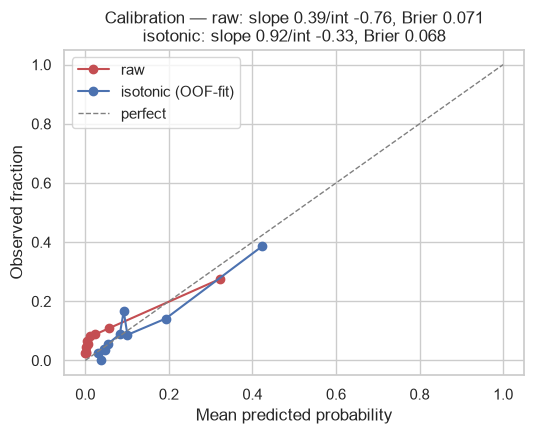

In [8]:
# --- Step 4: calibration — raw vs OOF-fitted isotonic ----------------------------------
# The isotonic mapping is fitted on TRAIN-only out-of-fold predictions, then applied to
# the hold-out. The hold-out is never used for its own recalibration.
oof = np.zeros(len(X_train_m))
for tr, va in CV5.split(X_train_m, y_train):
    m = make_model(**best_params)
    m.fit(X_train_m.iloc[tr], y_train.iloc[tr], **FIT_KWARGS)
    oof[va] = m.predict_proba(X_train_m.iloc[va])[:, 1]

from sklearn.isotonic import IsotonicRegression
iso = IsotonicRegression(out_of_bounds="clip").fit(oof, y_train)
proba_iso = iso.predict(proba_raw)

slope_raw, int_raw = calib_slope_intercept(y_test, proba_raw)
slope_iso, int_iso = calib_slope_intercept(y_test, proba_iso)
brier_iso = brier_score_loss(y_test, proba_iso)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
for p, c, lbl in [(proba_raw, "#c44e52", "raw"), (proba_iso, "#4c72b0", "isotonic (OOF-fit)")]:
    frac, mean_p = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
    ax.plot(mean_p, frac, "o-", color=c, label=lbl)
ax.plot([0, 1], [0, 1], "--", c="grey", lw=1, label="perfect")
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Observed fraction")
ax.set_title(f"Calibration — raw: slope {slope_raw:.2f}/int {int_raw:.2f}, Brier {brier_raw:.3f}\n"
             f"isotonic: slope {slope_iso:.2f}/int {int_iso:.2f}, Brier {brier_iso:.3f}")
ax.legend()
plt.tight_layout(); plt.show()


In [9]:
# --- Step 5: subgroup performance (fairness drift check, modelx §8) --------------------
subgroups = []
for col, label in [("sex", "Sex"), ("residence", "Residence")]:
    for grp in X_test[col].dropna().unique():
        m = (X_test[col] == grp).values
        if m.sum() and y_test[m].sum() > 0:
            subgroups.append({
                "subgroup": f"{label}: {grp}", "n": int(m.sum()),
                "events": int(y_test[m].sum()),
                "ROC-AUC": roc_auc_score(y_test[m], proba_raw[m]),
                "mean_pred": proba_raw[m].mean(), "observed": y_test[m].mean(),
            })
sub_df = pd.DataFrame(subgroups)
display(sub_df.round(3))
print("Drift check: compare mean_pred vs observed (calibration) per row.")


,subgroup,n,events,ROC-AUC,mean_pred,observed
0,Sex: Male,1070,83,0.738,0.039,0.078
1,Sex: Female,1315,109,0.712,0.047,0.083
2,Residence: Rural,1579,134,0.714,0.044,0.085
3,Residence: Urban,806,58,0.745,0.041,0.072


Drift check: compare mean_pred vs observed (calibration) per row.


## 4 · Interpretation

,feature,importance,sd
0,age_years,0.1454,0.0125
1,systolic_bp_mmhg,0.0094,0.0052
2,lives_alone,0.0043,0.0026
3,gds15_score,0.0040,0.0039
4,prior_stroke,0.0038,0.0013
5,hypertension_dx,0.0034,0.0031
6,family_history_dementia,0.0028,0.0028
7,diabetes_dx,0.0024,0.0013
8,vision_difficulty,0.0024,0.0041
9,province,0.0021,0.0030


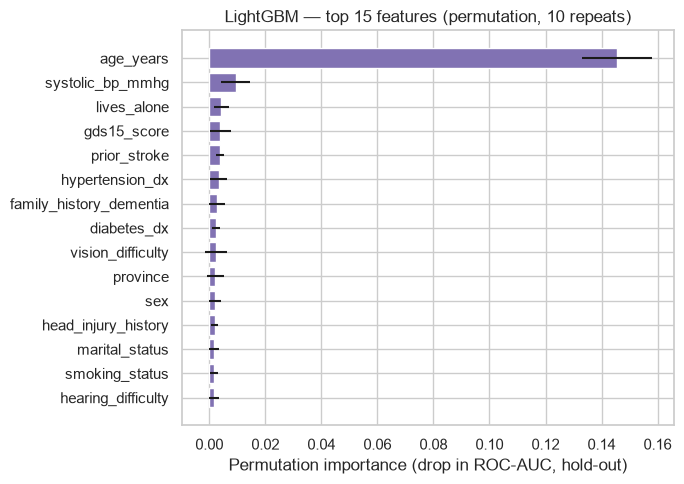

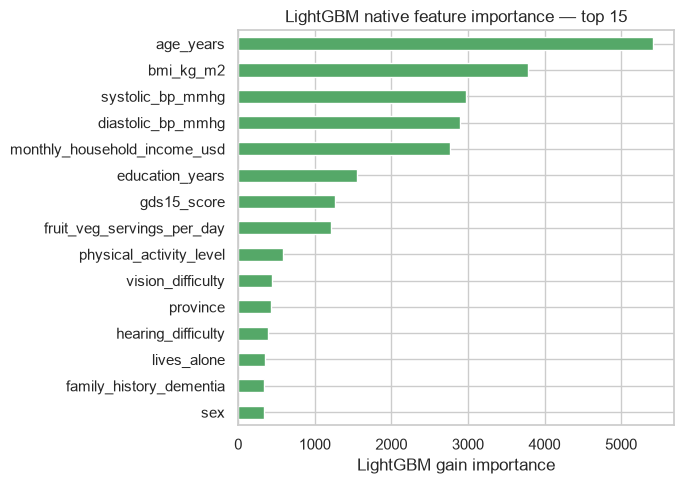

In [10]:
# --- Step 6: what drives the model — permutation importance (model-agnostic) ----------
perm = permutation_importance(final_model, X_test_m, y_test, scoring="roc_auc",
                              n_repeats=10, random_state=RANDOM_STATE, n_jobs=1)
perm_tab = (pd.DataFrame({"feature": X_test_m.columns,
                          "importance": perm.importances_mean,
                          "sd": perm.importances_std})
            .sort_values("importance", ascending=False).reset_index(drop=True))
display(perm_tab.head(15).round(4))

fig, ax = plt.subplots(figsize=(7, 5))
top = perm_tab.head(15).iloc[::-1]
ax.barh(top["feature"], top["importance"], xerr=top["sd"], color="#8172b3")
ax.set_xlabel("Permutation importance (drop in ROC-AUC, hold-out)")
ax.set_title(f"{MODEL_NAME} — top 15 features (permutation, 10 repeats)")
plt.tight_layout(); plt.show()

native_imp = pd.Series(final_model.feature_importances_, index=X_train_m.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
native_imp.tail(15).plot.barh(color="#55a868", ax=ax)
ax.set_xlabel("LightGBM gain importance")
ax.set_title("LightGBM native feature importance — top 15")
plt.tight_layout(); plt.show()



In [11]:
# --- Step 7: export artefacts for the cross-model comparison notebook ------------------
metrics = {
    "model": MODEL_NAME,
    "best_params": {k: (v.item() if hasattr(v, "item") else v) for k, v in best_params.items()},
    "cv_default": default_sum,
    "cv_tuned": tuned_sum,
    "holdout": {
        "roc_auc": float(auc), "pr_auc": float(pr_auc),
        "brier_raw": float(brier_raw), "brier_isotonic": float(brier_iso),
        "calib_slope_raw": slope_raw, "calib_intercept_raw": int_raw,
        "calib_slope_isotonic": slope_iso, "calib_intercept_isotonic": int_iso,
        "threshold_youden": float(thr_youden), "threshold_screen": float(thr_screen),
        "youden": {k: float(v) for k, v in points["Youden J"].items()},
        "screening": {k: float(v) for k, v in points["Screening (sens>=0.80)"].items()},
    },
    "subgroups": sub_df.round(4).to_dict(orient="records"),
    "perm_importance_top15": perm_tab.head(15).round(5).to_dict(orient="records"),
}
with open(BENCH / f"{SLUG}_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2, default=str)

pd.DataFrame({"y_true": y_test.values, "proba_raw": proba_raw, "proba_isotonic": proba_iso,
              "sex": X_test["sex"].values, "residence": X_test["residence"].values}
             ).to_csv(BENCH / f"{SLUG}_holdout_predictions.csv", index=False)

print("=" * 88)
print(f"{MODEL_NAME} vs LR incumbent — hold-out (n=2,385, 192 events)")
print(f"  ROC-AUC  {auc:.3f}  vs 0.771   ({auc - 0.771:+.3f})")
print(f"  PR-AUC   {pr_auc:.3f}  vs 0.337   ({pr_auc - 0.337:+.3f})")
print(f"  Brier    {brier_raw:.3f}  vs 0.063   ({brier_raw - 0.063:+.3f})   "
      f"[isotonic: {brier_iso:.3f}]")
sc = points["Screening (sens>=0.80)"]
print(f"  Screening point (sens>=0.80): sens {sc['sensitivity']:.3f} | spec {sc['specificity']:.3f} "
      f"| NPV {sc['NPV']:.3f}   [LR: 0.802 / 0.511 / 0.967]")
print("=" * 88)


LightGBM vs LR incumbent — hold-out (n=2,385, 192 events)
  ROC-AUC  0.725  vs 0.771   (-0.046)
  PR-AUC   0.260  vs 0.337   (-0.077)
  Brier    0.071  vs 0.063   (+0.008)   [isotonic: 0.068]
  Screening point (sens>=0.80): sens 0.802 | spec 0.456 | NPV 0.963   [LR: 0.802 / 0.511 / 0.967]


## Takeaways

- **Discrimination**: does the tuned hold-out AUC beat 0.771 by a meaningful margin? Check `model_comparison.ipynb` for the paired DeLong test against the LR incumbent — a point estimate alone is not evidence.
- **Calibration**: trees rarely self-calibrate; the OOF isotonic variant is the deployable probability source if the raw curve bends.
- **Interpretability**: gain importances only; same caveat as XGBoost.
- All artefacts: `outputs/benchmark/lightgbm_metrics.json`, `lightgbm_holdout_predictions.csv` — consumed by `model_comparison.ipynb`.
